# Remove Duplicate Images

This notebook scans a source folder for images, detects pixel-level duplicates using perceptual hashing, and copies only unique images to a new output folder.

**Rules:**
- The original source folder is **never modified**
- When duplicates are found, the **first encountered** image is kept
- All unique images are copied to the output folder, preserving subfolder structure

## 1. Configuration — Set Your Paths Here

In [1]:
# ─── CONFIGURE THESE TWO PATHS ───────────────────────────────────────────────

SOURCE_FOLDER = "/cluster/home/henrban/aquaculture-perception/data-processing/vision/SOLAQUA/raw_processed/all_images/2024-08-20_17-40-54"   # e.g. "/data/SOLAQUA/raw_processed/..."
OUTPUT_FOLDER = "/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-40-54/frames/2024-08-20_17-34-52_CLEAN"   

# ─── OPTIONAL SETTINGS ───────────────────────────────────────────────────────

# Supported image extensions (lowercase)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}

# Hash method: 'md5'  = exact pixel-level duplicates only (fastest)
#              'phash' = perceptual hash, catches near-identical images too
#                        (requires 'imagehash' library — pip install imagehash)
HASH_METHOD = "md5"   # Change to 'phash' for near-duplicate detection

# Only used when HASH_METHOD = 'phash'.
# Max hamming distance to consider two images duplicates (0 = identical, 10 = very similar)
PHASH_THRESHOLD = 5

print("✅ Configuration loaded.")
print(f"   Source : {SOURCE_FOLDER}")
print(f"   Output : {OUTPUT_FOLDER}")
print(f"   Method : {HASH_METHOD}")

✅ Configuration loaded.
   Source : /cluster/home/henrban/aquaculture-perception/data-processing/vision/SOLAQUA/raw_processed/all_images/2024-08-20_17-40-54
   Output : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-40-54/frames/2024-08-20_17-34-52_CLEAN
   Method : md5


## 2. Install / Import Dependencies

In [2]:
import sys
import os
import hashlib
import shutil
from pathlib import Path
from collections import defaultdict

from PIL import Image

if HASH_METHOD == "phash":
    try:
        import imagehash
    except ImportError:
        print("Installing imagehash ...")
        os.system(f"{sys.executable} -m pip install imagehash -q")
        import imagehash

print("✅ All imports successful.")

✅ All imports successful.


## 3. Helper Functions

In [3]:
def get_md5_hash(filepath: Path) -> str:
    """Return MD5 hash of raw file bytes — exact duplicate detection."""
    h = hashlib.md5()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()


def get_pixel_md5_hash(filepath: Path) -> str:
    """Return MD5 hash of decoded pixel data — catches same-content images
    saved with different compression or metadata."""
    with Image.open(filepath) as img:
        # Convert to RGB to normalise palette/RGBA differences
        pixel_bytes = img.convert("RGB").tobytes()
    return hashlib.md5(pixel_bytes).hexdigest()


def get_phash(filepath: Path) -> "imagehash.ImageHash":
    """Return perceptual hash — robust to minor edits, compression artefacts."""
    with Image.open(filepath) as img:
        return imagehash.phash(img)


def collect_images(source: Path, extensions: set) -> list[Path]:
    """Recursively collect all image files under *source*, sorted by path
    so that the first encountered (alphabetically) is always kept."""
    images = [
        p for p in sorted(source.rglob("*"))
        if p.is_file() and p.suffix.lower() in extensions
    ]
    return images


print("✅ Helper functions defined.")

✅ Helper functions defined.


## 4. Scan & Detect Duplicates

In [4]:
source_path = Path(SOURCE_FOLDER)
output_path = Path(OUTPUT_FOLDER)

assert source_path.exists(), f"Source folder not found: {source_path}"

print(f"🔍 Scanning: {source_path}")
all_images = collect_images(source_path, IMAGE_EXTENSIONS)
print(f"   Found {len(all_images)} image(s) in total.\n")

# ── Build hash → [list of paths] mapping ──────────────────────────────────────
seen_hashes: dict = {}          # hash → first (kept) path
kept:        list[Path] = []
duplicates:  list[tuple[Path, Path]] = []  # (duplicate, original)
errors:      list[tuple[Path, str]] = []

# For phash we need a list of (hash, path) to do threshold comparison
phash_registry: list[tuple] = []  # [(imagehash, path), ...]

for idx, img_path in enumerate(all_images, 1):
    print(f"  [{idx:>5}/{len(all_images)}] {img_path.name}", end="  ")

    try:
        if HASH_METHOD == "md5":
            h = get_pixel_md5_hash(img_path)
            if h in seen_hashes:
                print(f"→ DUPLICATE of {seen_hashes[h].name}")
                duplicates.append((img_path, seen_hashes[h]))
            else:
                seen_hashes[h] = img_path
                kept.append(img_path)
                print("→ unique ✓")

        elif HASH_METHOD == "phash":
            h = get_phash(img_path)
            match = None
            for existing_hash, existing_path in phash_registry:
                if (h - existing_hash) <= PHASH_THRESHOLD:
                    match = existing_path
                    break
            if match:
                print(f"→ DUPLICATE of {match.name}")
                duplicates.append((img_path, match))
            else:
                phash_registry.append((h, img_path))
                kept.append(img_path)
                print("→ unique ✓")

    except Exception as exc:
        print(f"→ ERROR: {exc}")
        errors.append((img_path, str(exc)))

print(f"\n{'─'*60}")
print(f"  Total images  : {len(all_images)}")
print(f"  Unique (keep) : {len(kept)}")
print(f"  Duplicates    : {len(duplicates)}")
print(f"  Errors        : {len(errors)}")
print(f"{'─'*60}")

🔍 Scanning: /cluster/home/henrban/aquaculture-perception/data-processing/vision/SOLAQUA/raw_processed/all_images/2024-08-20_17-40-54
   Found 1598 image(s) in total.

  [    1/1598] 1724168456981189900.jpg  → unique ✓
  [    2/1598] 1724168457013673800.jpg  → DUPLICATE of 1724168456981189900.jpg
  [    3/1598] 1724168457058782300.jpg  → unique ✓
  [    4/1598] 1724168457088701100.jpg  → DUPLICATE of 1724168457058782300.jpg
  [    5/1598] 1724168457136982000.jpg  → unique ✓
  [    6/1598] 1724168457181273100.jpg  → unique ✓
  [    7/1598] 1724168457210974800.jpg  → DUPLICATE of 1724168457181273100.jpg
  [    8/1598] 1724168457255348300.jpg  → unique ✓
  [    9/1598] 1724168457300512400.jpg  → unique ✓
  [   10/1598] 1724168457334756500.jpg  → DUPLICATE of 1724168457300512400.jpg
  [   11/1598] 1724168457376719400.jpg  → unique ✓
  [   12/1598] 1724168457409171800.jpg  → DUPLICATE of 1724168457376719400.jpg
  [   13/1598] 1724168457452790400.jpg  → unique ✓
  [   14/1598] 172416845750228

## 5. Preview Duplicate Groups

In [5]:
if not duplicates:
    print("🎉 No duplicates found — all images are unique!")
else:
    print(f"Found {len(duplicates)} duplicate image(s):\n")
    for dup, original in duplicates:
        # Show paths relative to source folder for readability
        print(f"  KEEP   → {original.relative_to(source_path)}")
        print(f"  REMOVE → {dup.relative_to(source_path)}")
        print()

Found 580 duplicate image(s):

  KEEP   → 1724168456981189900.jpg
  REMOVE → 1724168457013673800.jpg

  KEEP   → 1724168457058782300.jpg
  REMOVE → 1724168457088701100.jpg

  KEEP   → 1724168457181273100.jpg
  REMOVE → 1724168457210974800.jpg

  KEEP   → 1724168457300512400.jpg
  REMOVE → 1724168457334756500.jpg

  KEEP   → 1724168457376719400.jpg
  REMOVE → 1724168457409171800.jpg

  KEEP   → 1724168457502281000.jpg
  REMOVE → 1724168457529273400.jpg

  KEEP   → 1724168457650498300.jpg
  REMOVE → 1724168457697270600.jpg

  KEEP   → 1724168457742520200.jpg
  REMOVE → 1724168457773609500.jpg

  KEEP   → 1724168457848586900.jpg
  REMOVE → 1724168457896236900.jpg

  KEEP   → 1724168457941125200.jpg
  REMOVE → 1724168457971212800.jpg

  KEEP   → 1724168458062001300.jpg
  REMOVE → 1724168458092957600.jpg

  KEEP   → 1724168458169383000.jpg
  REMOVE → 1724168458215962200.jpg

  KEEP   → 1724168458289649600.jpg
  REMOVE → 1724168458335129500.jpg

  KEEP   → 1724168458410883300.jpg
  REMOVE → 

## 6. Visual Side-by-Side Preview of Duplicates (optional)

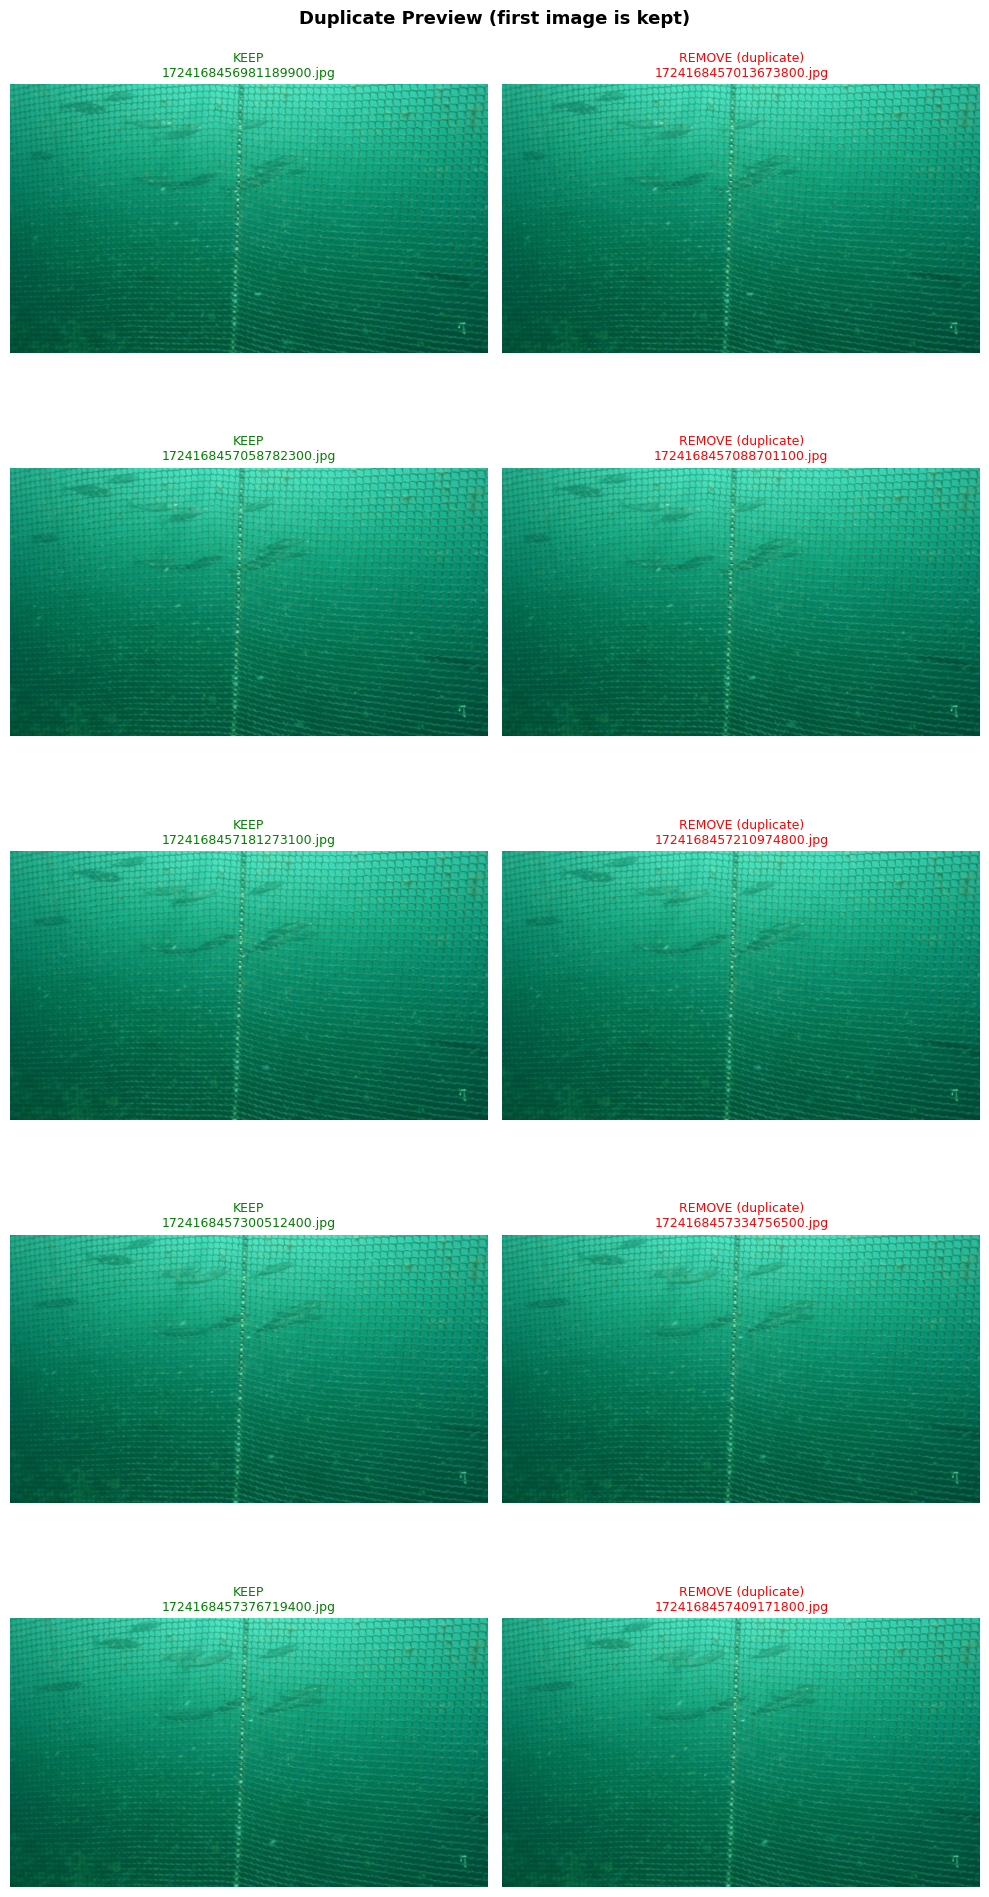

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

MAX_PREVIEW = 5  # Maximum duplicate pairs to display

if duplicates:
    preview_pairs = duplicates[:MAX_PREVIEW]
    fig, axes = plt.subplots(len(preview_pairs), 2,
                             figsize=(10, 4 * len(preview_pairs)))
    if len(preview_pairs) == 1:
        axes = [axes]  # Ensure iterable when only 1 pair

    for ax_row, (dup, original) in zip(axes, preview_pairs):
        for ax, path, label in [
            (ax_row[0], original, "KEEP"),
            (ax_row[1], dup,      "REMOVE (duplicate)"),
        ]:
            img = mpimg.imread(path)
            ax.imshow(img)
            ax.set_title(f"{label}\n{path.name}", fontsize=9, color="green" if label == "KEEP" else "red")
            ax.axis("off")

    plt.suptitle("Duplicate Preview (first image is kept)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No duplicates to preview.")

## 7. Copy Unique Images to Output Folder

In [7]:
# Safety check — confirm before writing
print(f"About to copy {len(kept)} unique image(s) to:")
print(f"  {output_path}\n")
print("Subfolder structure from the source folder will be preserved.")

confirm = input("Proceed? [y/N]: ").strip().lower()
if confirm != "y":
    print("Cancelled — no files were written.")
else:
    output_path.mkdir(parents=True, exist_ok=True)
    copied = 0
    copy_errors = []

    for img_path in kept:
        # Reproduce the same subfolder structure under output_path
        relative = img_path.relative_to(source_path)
        dest = output_path / relative
        dest.parent.mkdir(parents=True, exist_ok=True)

        try:
            shutil.copy2(img_path, dest)   # copy2 preserves metadata timestamps
            copied += 1
        except Exception as exc:
            copy_errors.append((img_path, str(exc)))
            print(f"  ⚠️  Failed to copy {img_path.name}: {exc}")

    print(f"\n✅ Done!")
    print(f"   Copied  : {copied} image(s)")
    print(f"   Skipped : {len(duplicates)} duplicate(s)")
    if copy_errors:
        print(f"   Errors  : {len(copy_errors)}")
    print(f"   Output  : {output_path}")

About to copy 1018 unique image(s) to:
  /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-40-54/frames/2024-08-20_17-34-52_CLEAN

Subfolder structure from the source folder will be preserved.

✅ Done!
   Copied  : 1018 image(s)
   Skipped : 580 duplicate(s)
   Output  : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-40-54/frames/2024-08-20_17-34-52_CLEAN


## 8. Save a Duplicate Report (CSV)

In [8]:
import csv
from datetime import datetime

report_path = output_path / f"duplicate_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

with open(report_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["action", "image_path", "duplicate_of"])

    for img_path in kept:
        writer.writerow(["kept", str(img_path), ""])

    for dup, original in duplicates:
        writer.writerow(["removed", str(dup), str(original)])

    for err_path, err_msg in errors:
        writer.writerow([f"error: {err_msg}", str(err_path), ""])

print(f"📄 Report saved to: {report_path}")

📄 Report saved to: /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-34-52/frames/2024-08-20_17-34-52_CLEAN/duplicate_report_20260522_134727.csv


---
## 9. Clean Annotation File — Remove Rows for Missing Frame IDs

After deduplication the output image folder may be missing some frame IDs that still exist in the annotation CSV.  
This cell:
1. Reads the annotation CSV (no header row assumed, first column = frame ID)
2. Builds the set of frame IDs present in the **output** image folder
3. Keeps only annotation rows whose frame ID has a matching image
4. Writes the cleaned annotations to a new file — the original is never modified

In [8]:
# ─── CONFIGURE ANNOTATION PATHS ──────────────────────────────────────────────

ANNOTATION_FILE   = "/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-55-40/gt/gt.txt"   # original annotation file
CLEANED_ANNO_FILE = "/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-55-40/gt/gt_clean.txt"  # output (never overwrites original)

# Column index (0-based) that holds the frame ID in the CSV
FRAME_ID_COLUMN = 0

# Does the annotation CSV have a header row?
HAS_HEADER = False

# Which image folder to use as the source of truth for surviving frame IDs.
# Defaults to OUTPUT_FOLDER set in Cell 1 (the deduplicated folder).
# Change to SOURCE_FOLDER if you want to validate against the original folder instead.
REFERENCE_IMAGE_FOLDER = OUTPUT_FOLDER

print("✅ Annotation config loaded.")
print(f"   Annotation in  : {ANNOTATION_FILE}")
print(f"   Annotation out : {CLEANED_ANNO_FILE}")
print(f"   Reference imgs : {REFERENCE_IMAGE_FOLDER}")

✅ Annotation config loaded.
   Annotation in  : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-55-40/gt/gt.txt
   Annotation out : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-55-40/gt/gt_clean.txt
   Reference imgs : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-55-40/frames/2024-08-20_17-55-40


In [9]:
import csv
from pathlib import Path

anno_path   = Path(ANNOTATION_FILE)
cleaned_path = Path(CLEANED_ANNO_FILE)
ref_path    = Path(REFERENCE_IMAGE_FOLDER)

assert anno_path.exists(),  f"Annotation file not found: {anno_path}"
assert ref_path.exists(),   f"Reference image folder not found: {ref_path}"

# ── Step 1: collect frame IDs present in the reference image folder ───────────
surviving_frame_ids: set[str] = set()
for p in ref_path.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
        surviving_frame_ids.add(p.stem)   # filename without extension = frame ID

print(f"🖼️  Frame IDs found in reference folder : {len(surviving_frame_ids)}")

# ── Step 2: filter the annotation file ───────────────────────────────────────
kept_rows    = []
removed_rows = []
header_row   = None

with open(anno_path, "r", newline="", encoding="utf-8") as f:
    reader = csv.reader(f)

    if HAS_HEADER:
        header_row = next(reader)

    for row in reader:
        if not row:          # skip blank lines
            continue
        frame_id = row[FRAME_ID_COLUMN].strip()
        if frame_id in surviving_frame_ids:
            kept_rows.append(row)
        else:
            removed_rows.append(row)

total_rows = len(kept_rows) + len(removed_rows)
print(f"📋 Total annotation rows  : {total_rows}")
print(f"   Rows kept             : {len(kept_rows)}")
print(f"   Rows removed          : {len(removed_rows)} (frame ID not in image folder)")

# ── Step 3: write the cleaned annotation file ─────────────────────────────────
cleaned_path.parent.mkdir(parents=True, exist_ok=True)

with open(cleaned_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    if HAS_HEADER and header_row is not None:
        writer.writerow(header_row)
    writer.writerows(kept_rows)

print(f"\n✅ Cleaned annotation file saved to:")
print(f"   {cleaned_path}")

🖼️  Frame IDs found in reference folder : 796
📋 Total annotation rows  : 2622
   Rows kept             : 1667
   Rows removed          : 955 (frame ID not in image folder)

✅ Cleaned annotation file saved to:
   /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-55-40/gt/gt_clean.txt


In [10]:
# ── Optional: preview the removed rows ───────────────────────────────────────
MAX_SHOW = 20

if not removed_rows:
    print("🎉 No annotation rows were removed — every frame ID has a matching image.")
else:
    print(f"First {min(MAX_SHOW, len(removed_rows))} removed annotation row(s):\n")
    for row in removed_rows[:MAX_SHOW]:
        frame_id = row[FRAME_ID_COLUMN]
        print(f"  frame_id={frame_id}  →  no matching image found, row removed")
    if len(removed_rows) > MAX_SHOW:
        print(f"  ... and {len(removed_rows) - MAX_SHOW} more (see cleaned CSV for full list)")

First 20 removed annotation row(s):

  frame_id=1724169344110130000  →  no matching image found, row removed
  frame_id=1724169344183310600  →  no matching image found, row removed
  frame_id=1724169344183310600  →  no matching image found, row removed
  frame_id=1724169344304662400  →  no matching image found, row removed
  frame_id=1724169344304662400  →  no matching image found, row removed
  frame_id=1724169344427912900  →  no matching image found, row removed
  frame_id=1724169344427912900  →  no matching image found, row removed
  frame_id=1724169344593367000  →  no matching image found, row removed
  frame_id=1724169344593367000  →  no matching image found, row removed
  frame_id=1724169344669195600  →  no matching image found, row removed
  frame_id=1724169344669195600  →  no matching image found, row removed
  frame_id=1724169344743939200  →  no matching image found, row removed
  frame_id=1724169344743939200  →  no matching image found, row removed
  frame_id=1724169344867438

---
## 10. Cut Trailing Digits from Image Filenames & Annotation Frame IDs

Timestamp-based filenames like `1724169343107751600.jpg` carry more digits than needed and can cause rounding issues downstream.  
This section:
1. Copies images from a source folder to a new output folder, renaming each file by removing N trailing digits from the stem
2. Rewrites the annotation file so every frame ID in column 0 is shortened by the same N digits
3. Detects ID collisions **before** writing anything, so you never silently overwrite files

**Neither the source image folder nor the original annotation file is modified.**

In [1]:
import shutil, csv
from pathlib import Path

# ─── CONFIGURE — set all paths here, this section is fully standalone ─────────

# Source folder containing the images to rename
CUT_SOURCE_FOLDER = '/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36_CUT_UNIQUE'

# Destination folder for the renamed images (must not already exist)
CUT_OUTPUT_FOLDER = '/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36'

# Annotation .txt/.csv file whose frame IDs should be shortened
CUT_ANNO_INPUT    = '/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt_CUT_UNIQUE/gt.txt'

# Where to write the digit-cut annotation file (original is never modified)
CUT_ANNO_OUTPUT   = '/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt/gt.txt'

# Number of trailing digits to remove from every numeric filename / frame ID
# Example: 1724169343107751600 -> 17241693431077516  when DIGITS_TO_CUT = 2
#          1724169343107751600 -> 1724169343107      when DIGITS_TO_CUT = 6
DIGITS_TO_CUT = 6

# Column index (0-based) of the frame ID in the annotation file
ANNO_FRAME_ID_COL = 0

# Does the annotation file have a header row?
ANNO_HAS_HEADER = False

# Supported image extensions
CUT_IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}

print('\u2705 Digit-cut config loaded.')
print(f'   Image source  : {CUT_SOURCE_FOLDER}')
print(f'   Image output  : {CUT_OUTPUT_FOLDER}')
print(f'   Anno input    : {CUT_ANNO_INPUT}')
print(f'   Anno output   : {CUT_ANNO_OUTPUT}')
print(f'   Digits to cut : {DIGITS_TO_CUT}')

✅ Digit-cut config loaded.
   Image source  : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36_CUT_UNIQUE
   Image output  : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36
   Anno input    : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt_CUT_UNIQUE/gt.txt
   Anno output   : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt/gt.txt
   Digits to cut : 6


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/cluster/home/henrban/aquaculture-perception/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/cluster/home/henrban/aquaculture-percepti

In [2]:
import shutil, csv
from pathlib import Path

# ── Helper ────────────────────────────────────────────────────────────────────
def cut_id(stem: str, n: int) -> str:
    """Remove n trailing digits from a purely numeric filename stem."""
    if not stem.isdigit():
        raise ValueError(f"Stem is not numeric: '{stem}'")
    if len(stem) <= n:
        raise ValueError(f"Cannot cut {n} digits from '{stem}' (only {len(stem)} digits)")
    return stem[:-n]


# ── Part A: rename and copy images ────────────────────────────────────────────
cut_src = Path(CUT_SOURCE_FOLDER)
cut_out = Path(CUT_OUTPUT_FOLDER)

assert cut_src.exists(), f'Source folder not found: {cut_src}'

if cut_out.exists():
    raise FileExistsError(
        f'Output folder already exists: {cut_out}\n'
        'Delete it or choose a different CUT_OUTPUT_FOLDER to avoid overwriting.'
    )

cut_out.mkdir(parents=True)

copied, skipped = 0, 0
seen_targets: set = set()

for img_path in sorted(cut_src.rglob('*')):
    if not img_path.is_file() or img_path.suffix.lower() not in CUT_IMAGE_EXTENSIONS:
        continue

    rel_parent = img_path.parent.relative_to(cut_src)
    target_dir = cut_out / rel_parent
    target_dir.mkdir(parents=True, exist_ok=True)

    try:
        new_stem = cut_id(img_path.stem, DIGITS_TO_CUT)
    except ValueError as e:
        print(f'  \u26a0\ufe0f  Skipping {img_path.name}: {e}')
        skipped += 1
        continue

    target_path = target_dir / (new_stem + img_path.suffix.lower())

    if target_path in seen_targets or target_path.exists():
        raise RuntimeError(
            f'ID collision detected!\n'
            f'  Original : {img_path}\n'
            f'  Target   : {target_path}\n'
            f'Cutting {DIGITS_TO_CUT} digits creates duplicate filenames. '
            'Try a smaller DIGITS_TO_CUT value.'
        )

    shutil.copy2(img_path, target_path)
    seen_targets.add(target_path)
    copied += 1

print(f'\U0001f5bc\ufe0f  Images done.')
print(f'   Copied  : {copied}')
print(f'   Skipped : {skipped}')
print(f'   Output  : {cut_out}')

🖼️  Images done.
   Copied  : 834
   Skipped : 0
   Output  : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/frames/2024-08-20_17-14-36


In [3]:
# ── Part B: shorten frame IDs in the annotation file ─────────────────────────
anno_in  = Path(CUT_ANNO_INPUT)
anno_out = Path(CUT_ANNO_OUTPUT)

assert anno_in.exists(), f'Annotation file not found: {anno_in}'

anno_out.parent.mkdir(parents=True, exist_ok=True)

written, anno_skipped, collisions = 0, 0, []
seen_cut_ids: set = set()

with open(anno_in,  'r', newline='', encoding='utf-8') as fin, \
     open(anno_out, 'w', newline='', encoding='utf-8') as fout:

    reader = csv.reader(fin)
    writer = csv.writer(fout)

    if ANNO_HAS_HEADER:
        writer.writerow(next(reader))

    for row in reader:
        if not row:
            continue

        original_id = row[ANNO_FRAME_ID_COL].strip()

        try:
            cut = cut_id(original_id, DIGITS_TO_CUT)
        except ValueError as e:
            print(f'  \u26a0\ufe0f  Skipping annotation row (frame_id={original_id}): {e}')
            anno_skipped += 1
            continue

        # Warn about collisions — two rows may legitimately share a truncated ID
        # if they came from very close timestamps. Raise an error here for strict mode.
        if cut in seen_cut_ids:
            collisions.append((original_id, cut))

        seen_cut_ids.add(cut)
        row[ANNO_FRAME_ID_COL] = cut
        writer.writerow(row)
        written += 1

print(f'\U0001f4cb Annotation done.')
print(f'   Rows written  : {written}')
print(f'   Rows skipped  : {anno_skipped}')
if collisions:
    print(f'   \u26a0\ufe0f  ID collisions (truncated IDs shared by multiple rows): {len(collisions)}')
    for orig, c in collisions[:10]:
        print(f'      {orig}  \u2192  {c}')
    if len(collisions) > 10:
        print(f'      ... and {len(collisions) - 10} more')
    print('   Consider using a smaller DIGITS_TO_CUT value if this is unexpected.')
else:
    print('   No ID collisions \u2014 all truncated frame IDs are unique \u2713')
print(f'   Output        : {anno_out}')

📋 Annotation done.
   Rows written  : 899
   Rows skipped  : 0
   ⚠️  ID collisions (truncated IDs shared by multiple rows): 418
      1724166879858545800  →  1724166879858
      1724166879893481900  →  1724166879893
      1724166879979820200  →  1724166879979
      1724166880012720500  →  1724166880012
      1724166880057762400  →  1724166880057
      1724166880087819000  →  1724166880087
      1724166880178981000  →  1724166880178
      1724166880209616300  →  1724166880209
      1724166880254275100  →  1724166880254
      1724166880300417200  →  1724166880300
      ... and 408 more
   Consider using a smaller DIGITS_TO_CUT value if this is unexpected.
   Output        : /cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_17-14-36/gt/gt.txt


---
## 11. Remap Frame IDs to CVAT Sequential Frame Numbers

CVAT numbers frames sequentially starting from 1, based on the **sorted order** of uploaded images.  
This section:
1. Reads the image folder and sorts filenames — this must match the upload order in CVAT
2. Builds a mapping: `timestamp_frame_id → sequential_frame_number` (1-indexed)
3. Rewrites the annotation file replacing the frame ID column with the CVAT frame number

**Run this after Section 10 (digit-cutting).** The original annotation file is never modified.

In [2]:
# ─── CONFIGURE — fully standalone, set all paths here ────────────────────────

# Folder containing the final images that will be uploaded to CVAT
# File sort order here must match the order CVAT receives them
CVAT_IMAGE_FOLDER = '/cluster/home/henrban/aquaculture-perception/data-processing/sonar/MOT/2024-08-20_17-39-32/frames'

# Annotation file with timestamp-based frame IDs (e.g. output from Section 10)
CVAT_ANNO_INPUT   = '/cluster/home/henrban/aquaculture-perception/data-processing/sonar/MOT/2024-08-20_17-39-32/gt/gt.txt'

# Output annotation file with CVAT sequential frame numbers
CVAT_ANNO_OUTPUT  = '/cluster/home/henrban/aquaculture-perception/data-processing/sonar/MOT/2024-08-20_17-39-32/gt_CVAT/gt.txt'

# Column index (0-based) of the frame ID in the annotation file
CVAT_FRAME_ID_COL = 0

# Does the annotation file have a header row?
CVAT_HAS_HEADER = False

# Supported image extensions
CVAT_IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}

# CVAT frame numbering start — CVAT starts at 0 by default in its internal API,
# but MOT format conventionally uses 1-based. Set to 0 if your CVAT export uses 0-based.
CVAT_FRAME_START = 1

print('\u2705 CVAT remap config loaded.')
print(f'   Image folder : {CVAT_IMAGE_FOLDER}')
print(f'   Anno input   : {CVAT_ANNO_INPUT}')
print(f'   Anno output  : {CVAT_ANNO_OUTPUT}')
print(f'   Frame start  : {CVAT_FRAME_START}')

✅ CVAT remap config loaded.
   Image folder : /cluster/home/henrban/aquaculture-perception/data-processing/sonar/MOT/2024-08-20_17-39-32/frames
   Anno input   : /cluster/home/henrban/aquaculture-perception/data-processing/sonar/MOT/2024-08-20_17-39-32/gt/gt.txt
   Anno output  : /cluster/home/henrban/aquaculture-perception/data-processing/sonar/MOT/2024-08-20_17-39-32/gt_CVAT/gt.txt
   Frame start  : 1


In [3]:
import csv
from pathlib import Path

cvat_img_dir   = Path(CVAT_IMAGE_FOLDER)
cvat_anno_in   = Path(CVAT_ANNO_INPUT)
cvat_anno_out  = Path(CVAT_ANNO_OUTPUT)

assert cvat_img_dir.exists(),  f'Image folder not found: {cvat_img_dir}'
assert cvat_anno_in.exists(),  f'Annotation file not found: {cvat_anno_in}'

# ── Step 1: build sorted list of image stems → sequential frame number ────────
# Sort must match exactly how CVAT receives the files (alphabetical by filename)
image_files = sorted(
    p for p in cvat_img_dir.rglob('*')
    if p.is_file() and p.suffix.lower() in CVAT_IMAGE_EXTENSIONS
)

# Map: filename stem (frame ID) -> CVAT sequential frame number
stem_to_cvat: dict = {
    p.stem: CVAT_FRAME_START + i
    for i, p in enumerate(image_files)
}

print(f'\U0001f5bc\ufe0f  Images found and sorted : {len(stem_to_cvat)}')
print(f'   Frame range : {CVAT_FRAME_START} \u2013 {CVAT_FRAME_START + len(stem_to_cvat) - 1}')
print()

# Preview first and last few mappings
items = list(stem_to_cvat.items())
print('   First 5 mappings:')
for stem, num in items[:5]:
    print(f'      {stem}  \u2192  frame {num}')
print('   ...')
print('   Last 5 mappings:')
for stem, num in items[-5:]:
    print(f'      {stem}  \u2192  frame {num}')

🖼️  Images found and sorted : 607
   Frame range : 1 – 607

   First 5 mappings:
      1724168374673946600  →  frame 1
      1724168374733567200  →  frame 2
      1724168374806817500  →  frame 3
      1724168374872236800  →  frame 4
      1724168374925284200  →  frame 5
   ...
   Last 5 mappings:
      1724168413202853600  →  frame 603
      1724168413269230700  →  frame 604
      1724168413325731700  →  frame 605
      1724168413400300900  →  frame 606
      1724168413460786900  →  frame 607


In [4]:
# ── Step 2: rewrite annotation with CVAT frame numbers ────────────────────────
cvat_anno_out.parent.mkdir(parents=True, exist_ok=True)

written, skipped_rows = 0, []

with open(cvat_anno_in,  'r', newline='', encoding='utf-8') as fin, \
     open(cvat_anno_out, 'w', newline='', encoding='utf-8') as fout:

    reader = csv.reader(fin)
    writer = csv.writer(fout)

    if CVAT_HAS_HEADER:
        writer.writerow(next(reader))

    for row in reader:
        if not row:
            continue

        frame_id = row[CVAT_FRAME_ID_COL].strip()

        if frame_id not in stem_to_cvat:
            skipped_rows.append(frame_id)
            continue

        row[CVAT_FRAME_ID_COL] = str(stem_to_cvat[frame_id])
        writer.writerow(row)
        written += 1

print(f'\U0001f4cb Annotation remapped.')
print(f'   Rows written : {written}')
print(f'   Rows skipped : {len(skipped_rows)} (frame ID not found in image folder)')
if skipped_rows:
    print(f'   \u26a0\ufe0f  Missing frame IDs (first 10):')
    for fid in skipped_rows[:10]:
        print(f'      {fid}')
    if len(skipped_rows) > 10:
        print(f'      ... and {len(skipped_rows) - 10} more')
print(f'   Output       : {cvat_anno_out}')

📋 Annotation remapped.
   Rows written : 853
   Rows skipped : 0 (frame ID not found in image folder)
   Output       : /cluster/home/henrban/aquaculture-perception/data-processing/sonar/MOT/2024-08-20_17-39-32/gt_CVAT/gt.txt


---
## 12. Sequence Summary Report

Prints a full summary of the final sequence — useful for documentation, debugging, and sanity-checking before uploading to CVAT.

**Fully standalone** — set the paths below and run independently.

In [14]:
# ─── CONFIGURE ────────────────────────────────────────────────────────────────

# Folder containing the final images (after dedup + digit cut)
SUMMARY_IMAGE_FOLDER = '/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_14-31-29/frames/2024-08-20_14-31-29'

# Final annotation file (timestamp-based frame IDs, e.g. output from Section 10)
# Set to None to skip annotation-based statistics
SUMMARY_ANNO_FILE    = '/cluster/home/henrban/aquaculture-perception/data-processing/vision/MOT/2024-08-20_14-31-29/gt/gt.txt'

# Column indices in the annotation file (0-based)
SUMMARY_FRAME_ID_COL  = 0   # timestamp frame ID
SUMMARY_TRACK_ID_COL  = 1   # object / track ID

# Does the annotation file have a header row?
SUMMARY_HAS_HEADER = False

# Supported image extensions
SUMMARY_IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}

print('\u2705 Summary config loaded.')

✅ Summary config loaded.


In [15]:
import csv
from pathlib import Path
from collections import defaultdict
from PIL import Image

summary_img_dir  = Path(SUMMARY_IMAGE_FOLDER)
assert summary_img_dir.exists(), f'Image folder not found: {summary_img_dir}'

# ── A: Image-level stats ──────────────────────────────────────────────────────
image_files = sorted(
    p for p in summary_img_dir.rglob('*')
    if p.is_file() and p.suffix.lower() in SUMMARY_IMAGE_EXTENSIONS
)

n_images = len(image_files)
assert n_images > 0, 'No images found in the folder.'

# Derive timestamps from filename stems (assumed numeric nanosecond timestamps)
timestamps_ns = []
for p in image_files:
    if p.stem.isdigit():
        timestamps_ns.append(int(p.stem))

has_timestamps = len(timestamps_ns) == n_images

# Image resolution (sample first image)
with Image.open(image_files[0]) as img:
    img_width, img_height = img.size

# Total file size
total_size_mb = sum(p.stat().st_size for p in image_files) / (1024 ** 2)

# ── B: Timing stats ───────────────────────────────────────────────────────────
if has_timestamps:
    t_start_ns = timestamps_ns[0]
    t_end_ns   = timestamps_ns[-1]
    duration_s = (t_end_ns - t_start_ns) / 1e9

    # Inter-frame intervals
    intervals_s = [(timestamps_ns[i+1] - timestamps_ns[i]) / 1e9
                   for i in range(len(timestamps_ns) - 1)]
    avg_interval_s = sum(intervals_s) / len(intervals_s) if intervals_s else 0
    avg_hz         = 1.0 / avg_interval_s if avg_interval_s > 0 else 0
    min_hz         = 1.0 / max(intervals_s) if intervals_s else 0
    max_hz         = 1.0 / min(intervals_s) if intervals_s else 0

# ── C: Annotation stats ───────────────────────────────────────────────────────
anno_stats = None
if SUMMARY_ANNO_FILE:
    anno_path = Path(SUMMARY_ANNO_FILE)
    assert anno_path.exists(), f'Annotation file not found: {anno_path}'

    image_stems = {p.stem for p in image_files}

    frames_with_objects: set = set()   # frame IDs that have at least one annotation
    track_ids: set = set()
    objects_per_frame: dict = defaultdict(int)
    track_lengths: dict = defaultdict(int)  # track_id -> number of frames it appears in
    total_anno_rows = 0

    with open(anno_path, 'r', newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        if SUMMARY_HAS_HEADER:
            next(reader)
        for row in reader:
            if not row:
                continue
            total_anno_rows += 1
            fid = row[SUMMARY_FRAME_ID_COL].strip()
            tid = row[SUMMARY_TRACK_ID_COL].strip()
            frames_with_objects.add(fid)
            track_ids.add(tid)
            objects_per_frame[fid] += 1
            track_lengths[tid] += 1

    n_frames_with_objects  = len(frames_with_objects)
    n_background_frames    = n_images - n_frames_with_objects
    n_tracks               = len(track_ids)
    avg_objects_per_frame  = total_anno_rows / n_frames_with_objects if n_frames_with_objects else 0
    max_objects_in_frame   = max(objects_per_frame.values()) if objects_per_frame else 0
    avg_track_length       = sum(track_lengths.values()) / len(track_lengths) if track_lengths else 0
    min_track_length       = min(track_lengths.values()) if track_lengths else 0
    max_track_length       = max(track_lengths.values()) if track_lengths else 0

    anno_stats = True

# ── D: Print report ───────────────────────────────────────────────────────────
W = 52
print('\u250c' + '\u2500' * W + '\u2510')
print(f'\u2502  {"SEQUENCE SUMMARY REPORT":<{W-2}}\u2502')
print('\u251c' + '\u2500' * W + '\u2524')

print(f'\u2502  {"IMAGES":<{W-2}}\u2502')
print(f'\u2502    Total images          : {n_images:<{W-28}}\u2502')
print(f'\u2502    Resolution            : {img_width} x {img_height} px{"":<{W-38}}\u2502')
print(f'\u2502    Total size on disk    : {total_size_mb:.1f} MB{"":<{W-32}}\u2502')
print(f'\u2502    Folder                : {str(summary_img_dir)[-40:]:<{W-28}}\u2502')

if has_timestamps:
    from datetime import datetime, timezone
    t_start_str = datetime.fromtimestamp(t_start_ns / 1e9, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')
    t_end_str   = datetime.fromtimestamp(t_end_ns   / 1e9, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')
    print('\u251c' + '\u2500' * W + '\u2524')
    print(f'\u2502  {"TIMING":<{W-2}}\u2502')
    print(f'\u2502    Start time            : {t_start_str:<{W-28}}\u2502')
    print(f'\u2502    End time              : {t_end_str:<{W-28}}\u2502')
    print(f'\u2502    Duration              : {duration_s:.2f} s  ({duration_s/60:.2f} min){"":<{W-42}}\u2502')
    print(f'\u2502    Avg frame rate        : {avg_hz:.2f} Hz{"":<{W-31}}\u2502')
    print(f'\u2502    Frame rate range      : {min_hz:.2f} \u2013 {max_hz:.2f} Hz{"":<{W-36}}\u2502')
    print(f'\u2502    Avg inter-frame gap   : {avg_interval_s*1000:.2f} ms{"":<{W-33}}\u2502')

if anno_stats:
    print('\u251c' + '\u2500' * W + '\u2524')
    print(f'\u2502  {"ANNOTATIONS":<{W-2}}\u2502')
    print(f'\u2502    Total annotation rows : {total_anno_rows:<{W-28}}\u2502')
    print(f'\u2502    Unique track IDs      : {n_tracks:<{W-28}}\u2502')
    print(f'\u2502    Frames with objects   : {n_frames_with_objects:<{W-28}}\u2502')
    print(f'\u2502    Background frames     : {n_background_frames} ({100*n_background_frames/n_images:.1f}%){"":<{W-38}}\u2502')
    print(f'\u2502    Avg objects/frame     : {avg_objects_per_frame:.2f}{"":<{W-29}}\u2502')
    print(f'\u2502    Max objects in frame  : {max_objects_in_frame:<{W-28}}\u2502')
    print('\u251c' + '\u2500' * W + '\u2524')
    print(f'\u2502  {"TRACK LENGTHS (frames per track)":<{W-2}}\u2502')
    print(f'\u2502    Avg track length      : {avg_track_length:.1f} frames{"":<{W-34}}\u2502')
    print(f'\u2502    Min track length      : {min_track_length} frames{"":<{W-33}}\u2502')
    print(f'\u2502    Max track length      : {max_track_length} frames{"":<{W-33}}\u2502')
    if has_timestamps:
        avg_track_dur_s = avg_track_length * avg_interval_s
        print(f'\u2502    Avg track duration    : {avg_track_dur_s:.2f} s{"":<{W-31}}\u2502')
    print('\u251c' + '\u2500' * W + '\u2524')
    print(f'\u2502  {"PER-TRACK BREAKDOWN":<{W-2}}\u2502')
    for tid in sorted(track_ids, key=lambda x: int(x) if x.isdigit() else x):
        tlen = track_lengths[tid]
        print(f'\u2502    Track {tid:<6} : {tlen:>5} frames{"":<{W-30}}\u2502')

print('\u2514' + '\u2500' * W + '\u2518')

┌────────────────────────────────────────────────────┐
│  SEQUENCE SUMMARY REPORT                           │
├────────────────────────────────────────────────────┤
│  IMAGES                                            │
│    Total images          : 1500                    │
│    Resolution            : 1280 x 720 px              │
│    Total size on disk    : 402.2 MB                    │
│    Folder                : 8-20_14-31-29/frames/2024-08-20_14-31-29│
├────────────────────────────────────────────────────┤
│  TIMING                                            │
│    Start time            : 2024-08-20 12:31:31 UTC │
│    End time              : 2024-08-20 12:32:39 UTC │
│    Duration              : 67.48 s  (1.12 min)          │
│    Avg frame rate        : 22.22 Hz                     │
│    Frame rate range      : 10.38 – 57.93 Hz                │
│    Avg inter-frame gap   : 45.01 ms                   │
├────────────────────────────────────────────────────┤
│  ANNOTATIONS       